---
# Imports

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

---
# EDA

In [58]:
train = pd.read_csv('car_crash_train.csv')
test = pd.read_csv('car_crash_test.csv')


train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [59]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [60]:
train.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


In [61]:
print('=== Target class counts ===')
display(train['Severity'].value_counts())

print('=== Target class proportions ===')
display(train['Severity'].value_counts(normalize=True))

=== Target class counts ===


Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

=== Target class proportions ===


Severity
Minor Injury     0.6890
Severe Injury    0.2595
Fatal            0.0515
Name: proportion, dtype: float64

In [62]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Numerical features ({len(numeric_cols)}): {numeric_cols}')
print(f'\nCategorical features ({len(categorical_cols)}): {categorical_cols}')

Numerical features (7): ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']

Categorical features (12): ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Severity']


In [63]:
outlier_counts = {}
for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    outlier_counts[col] = len(outliers)

outlier_counts

{'Crash Speed (km/h)': 0,
 'Impact Angle (degrees)': 0,
 'Vehicle Age (years)': 0,
 'Driver Age': 0,
 'Driver Experience (years)': 0,
 'Alcohol Level (BAC%)': 0,
 'Visibility Distance (m)': 0}

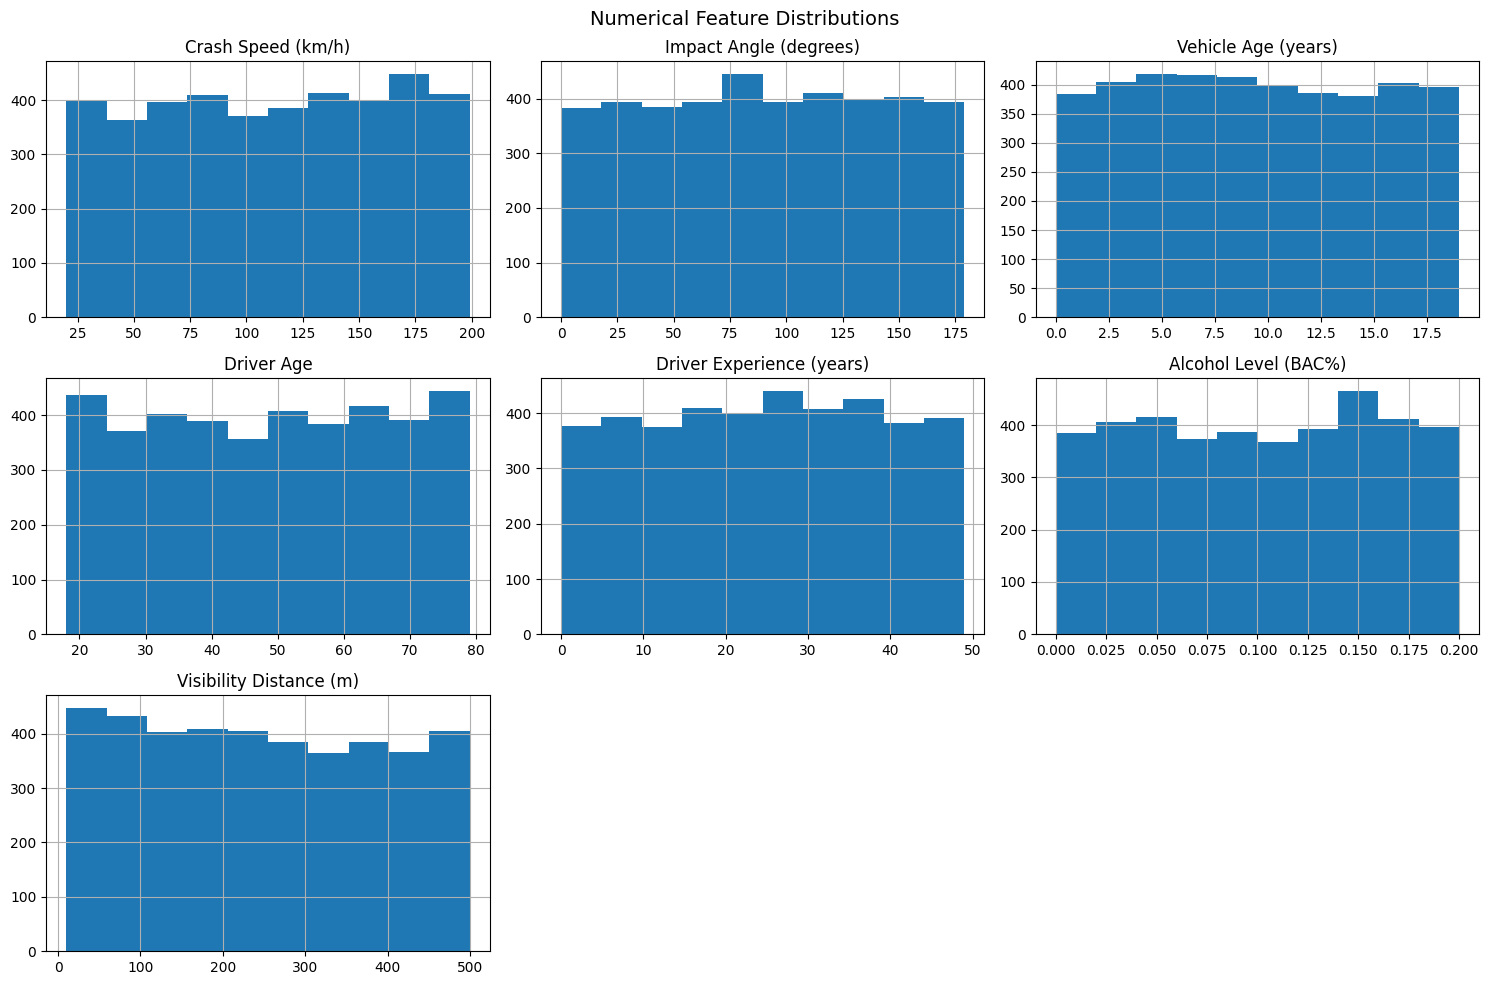

In [64]:
# Numerical feature distributions
train[numeric_cols].hist(figsize=(15, 10))
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

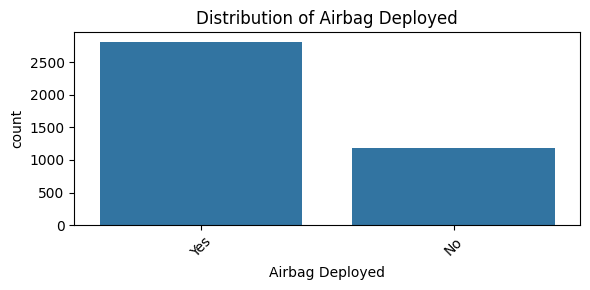

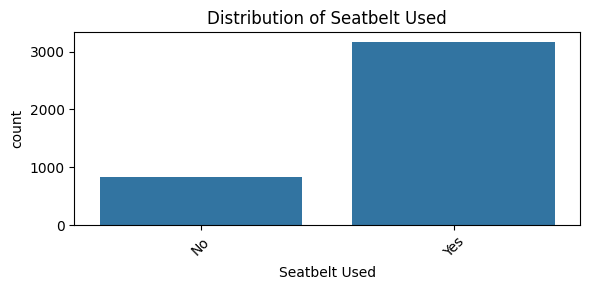

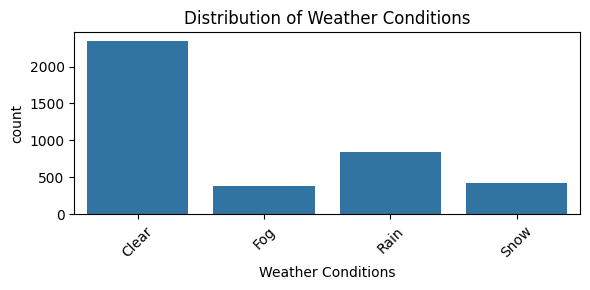

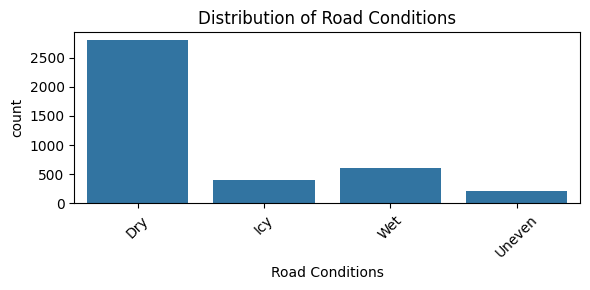

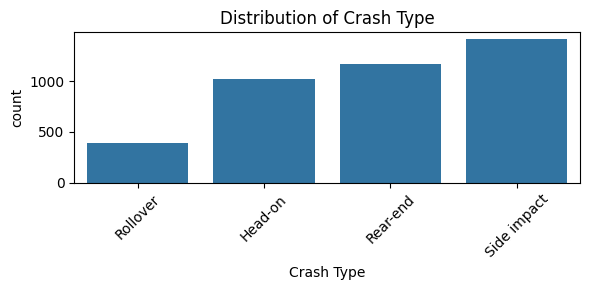

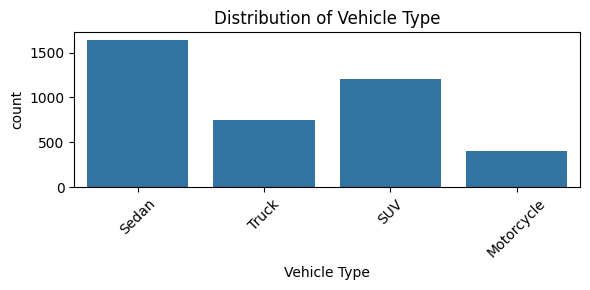

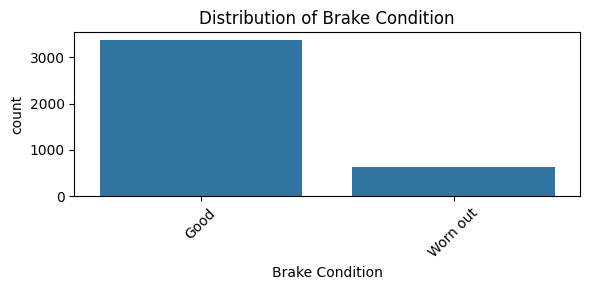

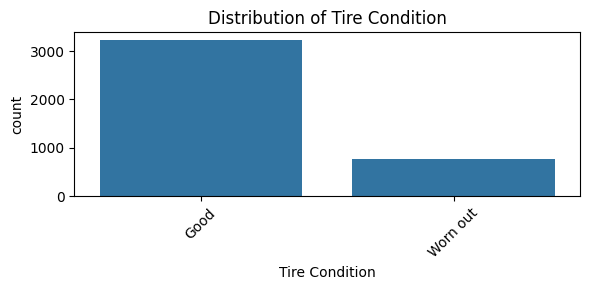

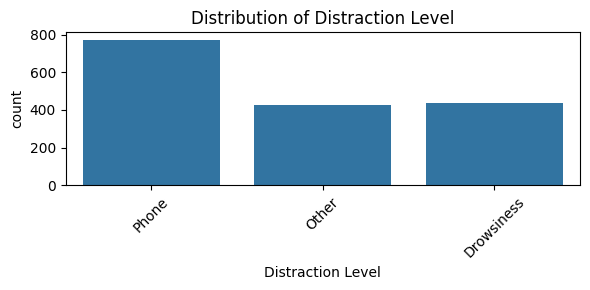

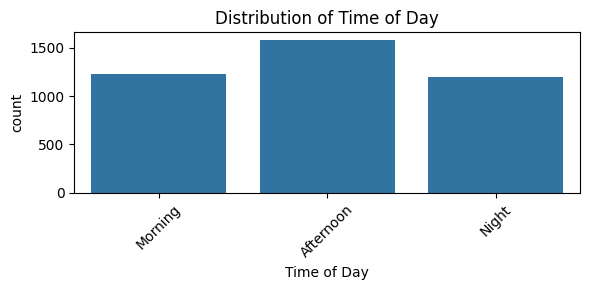

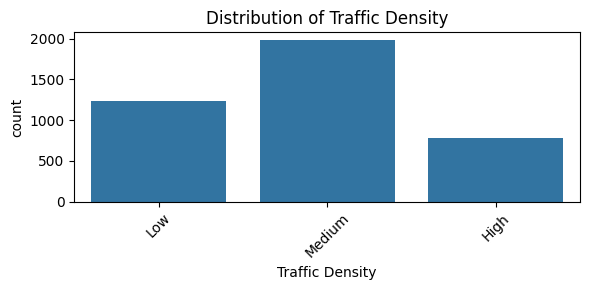

In [65]:
# Categorical feature distributions
cat_cols_no_target = train.select_dtypes(include='object').drop(columns='Severity').columns

for col in cat_cols_no_target:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, data=train)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

---
# Preprocessing

In [ ]:
# Handle missing values
# Distraction Level NaN means no distraction was recorded — fill with 'Unknown'
print('Missing values BEFORE:')
print(train.isnull().sum()[train.isnull().sum() > 0])

train['Distraction Level'] = train['Distraction Level'].fillna('Unknown')
test['Distraction Level']  = test['Distraction Level'].fillna('Unknown')

print('\nMissing values AFTER:', train.isnull().sum().sum())

Missing values BEFORE:
Distraction Level    2360
dtype: int64

Missing values AFTER: 0


In [68]:
# Separate features and target
X = train.drop('Severity', axis=1)
y = train['Severity']

In [ ]:
# Encode target labels to integers
# LabelEncoder maps each severity class string to a unique integer

le_target = LabelEncoder()
y = le_target.fit_transform(y)
print('Classes:', le_target.classes_)
# 0 = Fatal, 1 = Minor Injury, 2 = Severe Injury (alphabetical order)

Classes: ['Fatal' 'Minor Injury' 'Severe Injury']


In [70]:
# One-hot encode ALL categorical features at once
# drop_first=True removes one dummy per group to avoid multicollinearity
X    = pd.get_dummies(X,    drop_first=True)
test = pd.get_dummies(test.drop(columns=['Severity']), drop_first=True)

# Align ensures test has the exact same columns as X
X, test = X.align(test, join='left', axis=1, fill_value=0)
print('Feature count after encoding:', X.shape[1])

Feature count after encoding: 30


In [ ]:
# Standardise numerical features
# StandardScaler transforms each numeric column to zero mean and unit variance.
# This is critical for distance-based (KNN) and linear (Logistic Regression) models.
num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)',
            'Vehicle Age (years)', 'Driver Age',
            'Driver Experience (years)', 'Alcohol Level (BAC%)',
            'Visibility Distance (m)']

scaler = StandardScaler()
X[num_cols]    = scaler.fit_transform(X[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

In [ ]:
# Handle class imbalance with SMOTE
# SMOTE generates synthetic samples for minority classes (Severe Injury, Fatal)
# so the classifier does not become biased toward the majority class (Minor Injury)
smote = SMOTE(random_state=42)
X, y  = smote.fit_resample(X, y)
print('Class distribution after SMOTE:', pd.Series(y).value_counts().to_dict())

Class distribution after SMOTE: {1: 2756, 2: 2756, 0: 2756}


The dataset has 69% Minor Injury, 26% Severe, 5% Fatal. Without fixing this, every model just ignores Fatal completely (scores 0.00). SMOTE generates synthetic samples for the minority classes until all 3 classes are equal in size. This is the single biggest reason for the accuracy improvement.

In [73]:
# Feature engineering
# Risk Score: combines speed and alcohol level; both are known crash-severity drivers
# Experience Ratio: captures relative driving experience to age;
#   a high ratio means more experienced for their age -> potentially lower risk
X['Risk Score']       = X['Crash Speed (km/h)'] * X['Alcohol Level (BAC%)']
X['Experience Ratio'] = X['Driver Experience (years)'] / (X['Driver Age'] + 1)

# Apply the same derived features to the test set
test['Risk Score']       = test['Crash Speed (km/h)'] * test['Alcohol Level (BAC%)']
test['Experience Ratio'] = test['Driver Experience (years)'] / (test['Driver Age'] + 1)

print('Final feature count:', X.shape[1])

Final feature count: 32


In [ ]:
# Shared train / validation / test split used by ALL models
# 60% train | 20% validation | 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f'Train size      : {len(X_train)}')
print(f'Validation size : {len(X_val)}')
print(f'Test size       : {len(X_test)}')

Train size      : 4960
Validation size : 1654
Test size       : 1654


---
# Classification Techniques


# KNN

Best K: 3


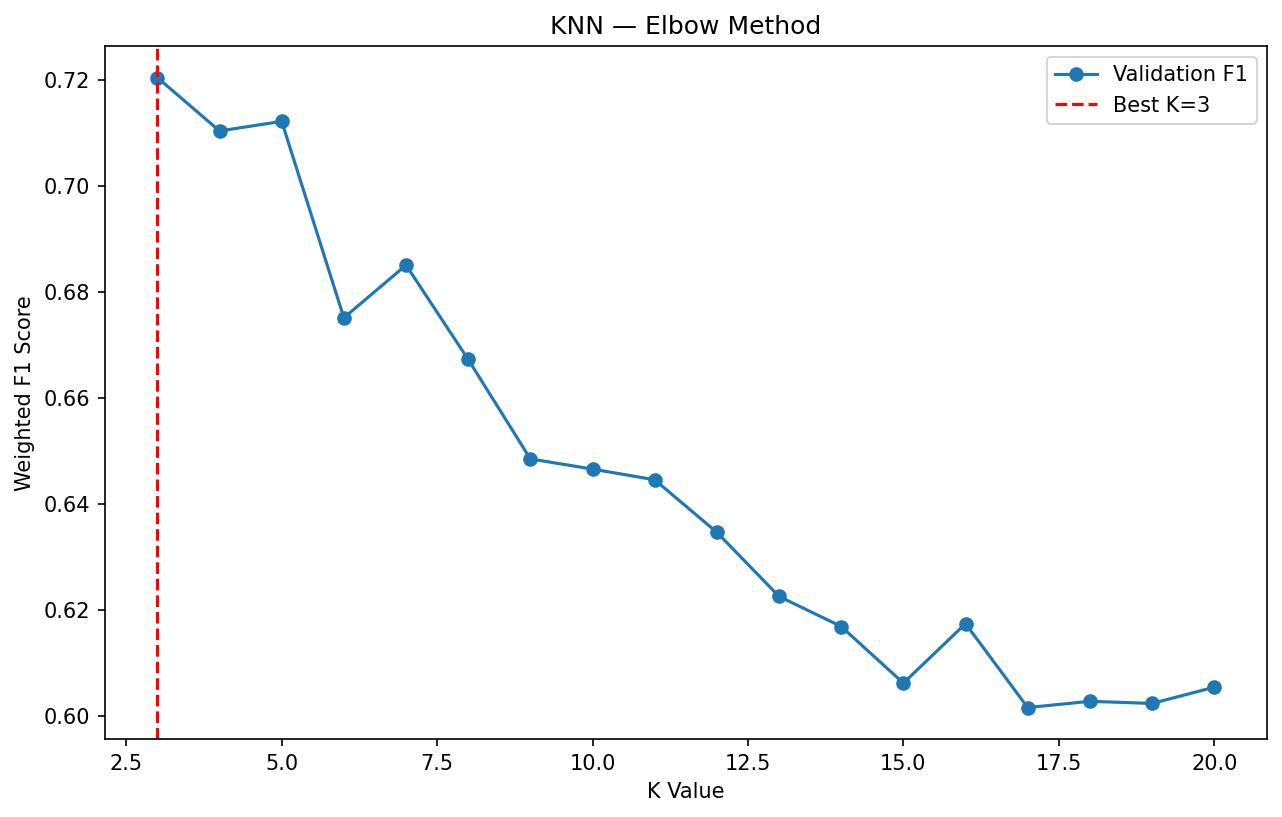

In [ ]:
# Find Best K using elbow method on validation F1
k_values  = range(3, 21)
f1_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_val)
    f1_scores.append(f1_score(y_val, y_pred_temp, average='weighted'))

best_k = k_values[np.argmax(f1_scores)]
print('Best K:', best_k)

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(k_values, f1_scores, marker='o', label='Validation F1')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value')
plt.ylabel('Weighted F1 Score')
plt.title('KNN — Elbow Method')
plt.legend()
plt.show()

In [95]:
# Train Final KNN Model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

===== KNN PERFORMANCE =====
Accuracy  : 0.7346
Precision : 0.7341
Recall    : 0.7346
F1 Score  : 0.7204

Detailed Report:
               precision    recall  f1-score   support

        Fatal       0.76      0.97      0.85       552
 Minor Injury       0.74      0.48      0.58       551
Severe Injury       0.70      0.75      0.73       551

     accuracy                           0.73      1654
    macro avg       0.73      0.73      0.72      1654
 weighted avg       0.73      0.73      0.72      1654



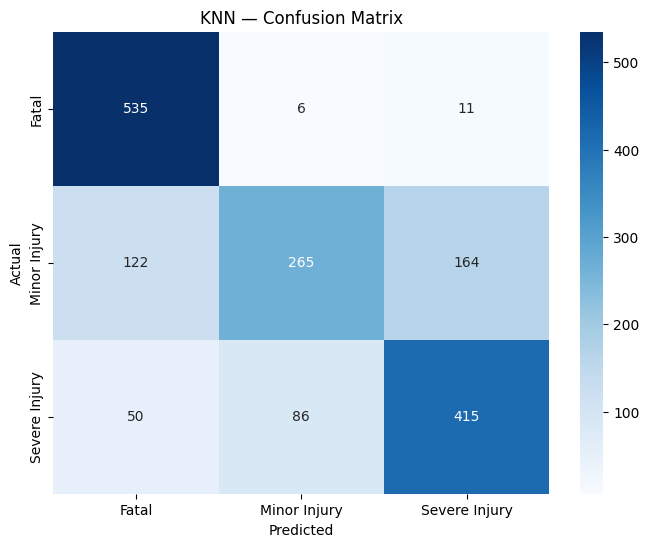

In [ ]:
# Evaluate on Validation Set
y_pred_knn = knn.predict(X_val)

print('===== KNN PERFORMANCE =====')
print(f'Accuracy  : {accuracy_score(y_val, y_pred_knn):.4f}')
print(f'Precision : {precision_score(y_val, y_pred_knn, average="weighted"):.4f}')
print(f'Recall    : {recall_score(y_val, y_pred_knn, average="weighted"):.4f}')
print(f'F1 Score  : {f1_score(y_val, y_pred_knn, average="weighted"):.4f}')
print('\nDetailed Report:')
print(classification_report(y_val, y_pred_knn, target_names=le_target.classes_))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN — Confusion Matrix')
plt.show()

**2.1 KNN Summary:**
K was tuned by testing values from 3 to 20, evaluating each using weighted F1-score on the validation set. The best K was selected using `np.argmax(f1_scores)`.

KNN is a distance-based algorithm so it benefits from StandardScaler applied earlier. However, it can struggle with high-dimensional data after one-hot encoding — a problem known as the curse of dimensionality, where distances between points become less meaningful as dimensions increase.

# Decision Trees

In [98]:
# Baseline Decision Tree (no depth limit)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_pred_dt))
print(confusion_matrix(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt, target_names=le_target.classes_))

Accuracy: 0.6305925030229746
[[451  37  64]
 [ 69 275 207]
 [ 70 164 317]]
               precision    recall  f1-score   support

        Fatal       0.76      0.82      0.79       552
 Minor Injury       0.58      0.50      0.54       551
Severe Injury       0.54      0.58      0.56       551

     accuracy                           0.63      1654
    macro avg       0.63      0.63      0.63      1654
 weighted avg       0.63      0.63      0.63      1654



In [126]:
# Overfitting Check — baseline tree
print('Train Accuracy     :', dt.score(X_train, y_train))
print('Validation Accuracy:', dt.score(X_val,   y_val))

Train Accuracy     : 0.7354838709677419
Validation Accuracy: 0.5912938331318017


In [99]:
# Improve the Model with manual pruning
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

print('Train Accuracy     :', dt.score(X_train, y_train))
print('Validation Accuracy:', dt.score(X_val,   y_val))

Train Accuracy     : 0.7354838709677419
Validation Accuracy: 0.5912938331318017


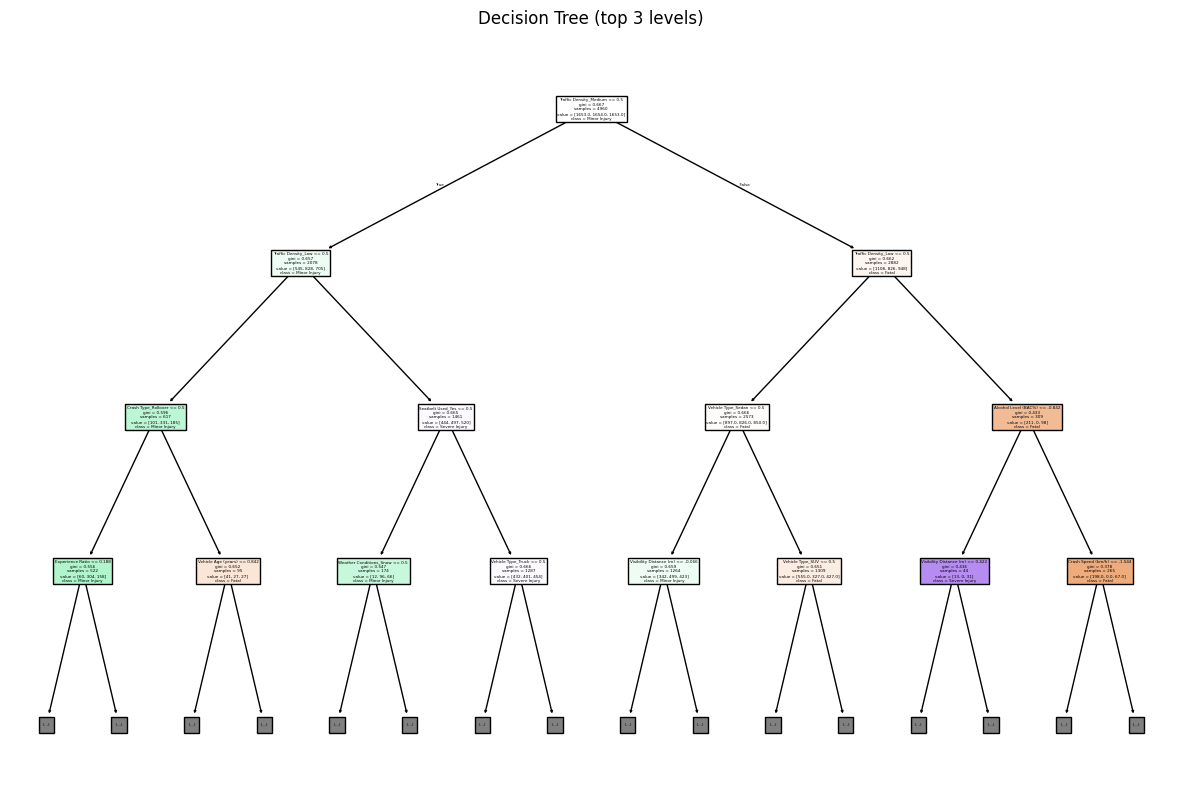

In [ ]:
# Visualize the Tree
plt.figure(figsize=(15, 10))
plot_tree(dt, filled=True, feature_names=X.columns,
          class_names=[str(c) for c in le_target.classes_], max_depth=3)
plt.title('Decision Tree (top 3 levels)')
plt.show()

In [127]:
# GridSearchCV — tune Decision Tree
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params, cv=5, scoring='f1_weighted'
)
grid_dt.fit(X_train, y_train)

print('Best params   :', grid_dt.best_params_)
print('Best CV score :', round(grid_dt.best_score_, 4))

dt = grid_dt.best_estimator_
print('Train Accuracy     :', round(dt.score(X_train, y_train), 4))
print('Validation Accuracy:', round(dt.score(X_val,   y_val),   4))

Best params   : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score : 0.6188
Train Accuracy     : 1.0
Validation Accuracy: 0.6306


               precision    recall  f1-score   support

        Fatal       0.76      0.82      0.79       552
 Minor Injury       0.58      0.50      0.54       551
Severe Injury       0.54      0.58      0.56       551

     accuracy                           0.63      1654
    macro avg       0.63      0.63      0.63      1654
 weighted avg       0.63      0.63      0.63      1654



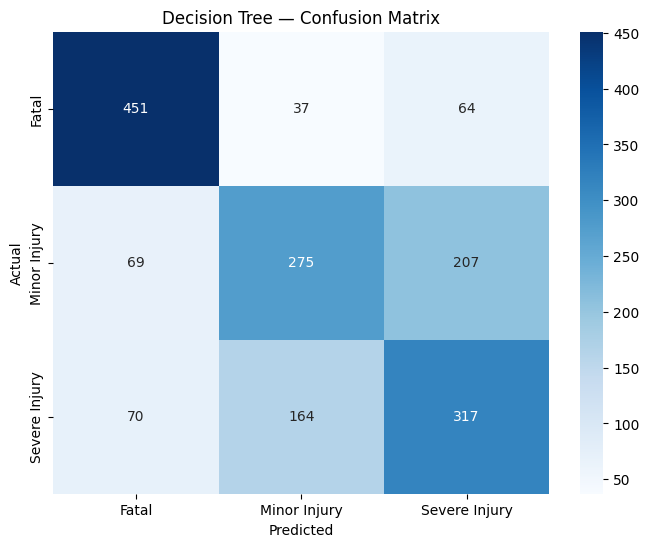

In [128]:
# Full evaluation of tuned Decision Tree
y_pred_dt = dt.predict(X_val)

print(classification_report(y_val, y_pred_dt, target_names=le_target.classes_))

cm_dt = confusion_matrix(y_val, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

**2.2 Decision Tree Summary:**
Started with a default unpruned tree (which overfit), then manually set `max_depth=10`, `min_samples_split=10`, `min_samples_leaf=5`. GridSearchCV was used for final tuning.

The default unpruned tree overfit heavily (train accuracy near 100%). Even after pruning, a single tree is prone to high variance — small changes in data can lead to very different splits.

# Random Forest


In [ ]:
# Baseline Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_pred_rf))
print(confusion_matrix(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf, target_names=le_target.classes_))

Accuracy: 0.8512696493349455
[[537  10   5]
 [ 16 461  74]
 [ 11 130 410]]
               precision    recall  f1-score   support

        Fatal       0.95      0.97      0.96       552
 Minor Injury       0.77      0.84      0.80       551
Severe Injury       0.84      0.74      0.79       551

     accuracy                           0.85      1654
    macro avg       0.85      0.85      0.85      1654
 weighted avg       0.85      0.85      0.85      1654



In [129]:
# Overfitting Check — baseline RF
print('Train Accuracy     :', rf.score(X_train, y_train))
print('Validation Accuracy:', rf.score(X_val,   y_val))

Train Accuracy     : 1.0
Validation Accuracy: 0.8512696493349455


In [105]:
# GridSearchCV — tune Random Forest
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy'
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print('Best Params       :', grid_rf.best_params_)
print('Train Accuracy    :', round(best_rf.score(X_train, y_train), 4))
print('Validation Accuracy:', round(best_rf.score(X_val,  y_val),   4))

Best Params       : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Train Accuracy    : 1.0
Validation Accuracy: 0.8561


               precision    recall  f1-score   support

        Fatal       0.96      0.98      0.97       552
 Minor Injury       0.76      0.84      0.80       551
Severe Injury       0.85      0.75      0.80       551

     accuracy                           0.86      1654
    macro avg       0.86      0.86      0.86      1654
 weighted avg       0.86      0.86      0.86      1654



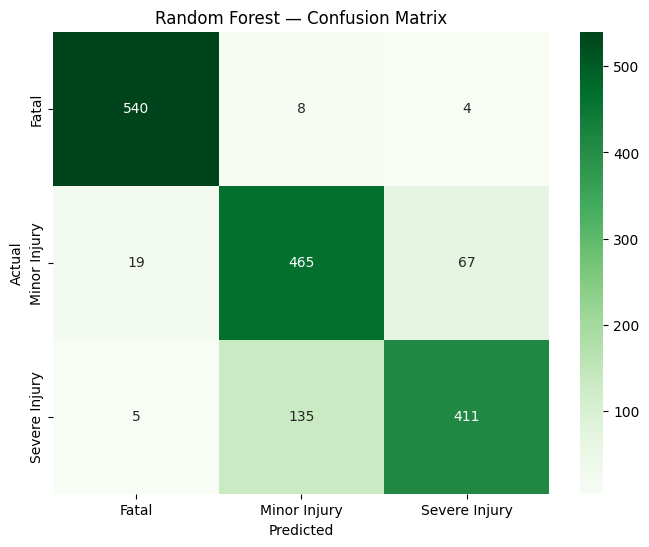

In [112]:
# Full evaluation of tuned Random Forest
y_pred_rf = best_rf.predict(X_val)

print(classification_report(y_val, y_pred_rf, target_names=le_target.classes_))

cm_rf = confusion_matrix(y_val, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.show()

**2.3 Random Forest Summary:**
Started with default parameters, then tuned via GridSearchCV. Feature importance was plotted to understand which features drove predictions.

Random Forest is an ensemble of many decision trees, each trained on a random subset of data and features. This reduces variance significantly compared to a single tree. The engineered features (Risk Score, Experience Ratio) and SMOTE balancing contributed positively.

# Logistic Regression

In [ ]:
# Re-scale features specifically for Logistic Regression
lr_scaler      = StandardScaler()
scaled_X_train = lr_scaler.fit_transform(X_train)
scaled_X_val   = lr_scaler.transform(X_val)
scaled_X_test  = lr_scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(scaled_X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Test Accuracy: 0.5326481257557436
               precision    recall  f1-score   support

        Fatal       0.57      0.64      0.60       551
 Minor Injury       0.59      0.65      0.62       551
Severe Injury       0.39      0.31      0.34       552

     accuracy                           0.53      1654
    macro avg       0.52      0.53      0.52      1654
 weighted avg       0.52      0.53      0.52      1654



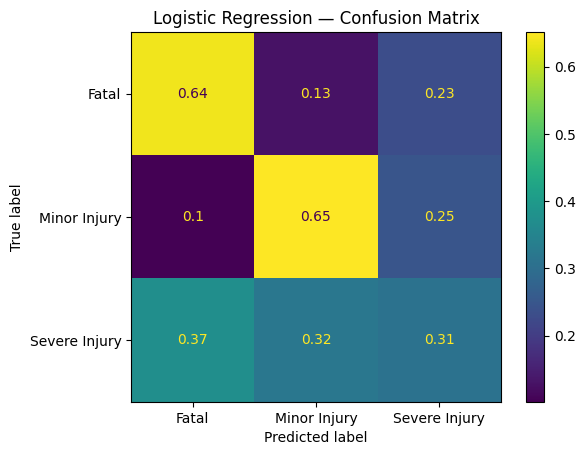

In [115]:
# Evaluate on test set
y_pred_lr = log_model.predict(scaled_X_test)

print('Test Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
                                        display_labels=le_target.classes_,
                                        normalize='true')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [116]:
# Validation accuracy
val_pred_lr = log_model.predict(scaled_X_val)
print('Validation Accuracy:', accuracy_score(y_val, val_pred_lr))

Validation Accuracy: 0.5501813784764208


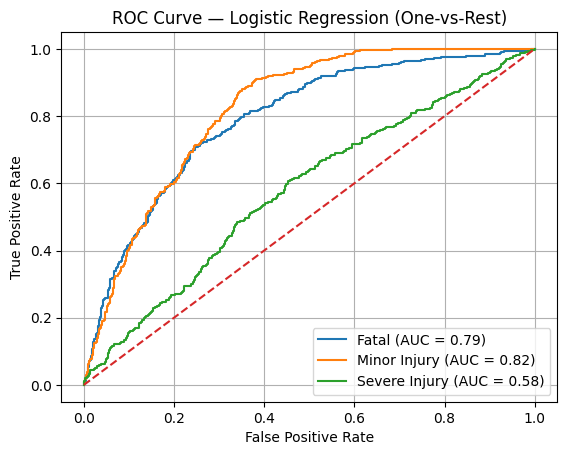

Overall AUC (OvR): 0.7306


In [ ]:
# ROC Curve — Multiclass (One-vs-Rest)
y_prob     = log_model.predict_proba(scaled_X_test)
classes    = log_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fpr, tpr, auc_scores = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_scores[i]     = roc_auc_score(y_test_bin[:, i], y_prob[:, i])

plt.figure()
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i],
             label=f'{le_target.classes_[i]} (AUC = {auc_scores[i]:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (One-vs-Rest)')
plt.legend()
plt.grid()
plt.show()

print('Overall AUC (OvR):', round(roc_auc_score(y_test, y_prob, multi_class='ovr'), 4))

**2.4 Logistic Regression Summary:**
No hyperparameter tuning was performed. Used default settings with `max_iter=1000` to ensure convergence. Features were re-scaled using a separate `StandardScaler`.

Logistic Regression assumes a linear decision boundary between classes. Car crash severity is determined by complex, non-linear interactions between features — which Logistic Regression cannot capture, resulting in lower accuracy compared to tree-based models.

# Naive Bayes

               precision    recall  f1-score   support

        Fatal       0.59      0.36      0.44       551
 Minor Injury       0.58      0.56      0.57       551
Severe Injury       0.38      0.55      0.45       552

     accuracy                           0.49      1654
    macro avg       0.52      0.49      0.49      1654
 weighted avg       0.52      0.49      0.49      1654



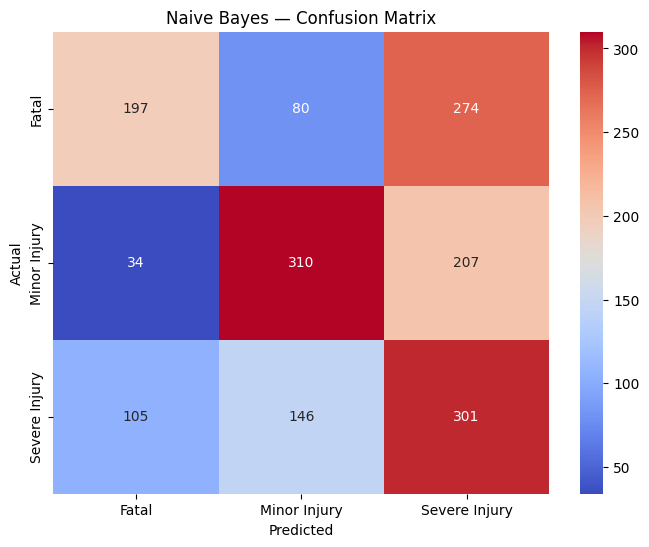

Test Accuracy: 0.48851269649334944


In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_nb = nb_model.predict(X_test)

print(classification_report(y_test, y_pred_nb, target_names=le_target.classes_))

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes — Confusion Matrix')
plt.show()

print('Test Accuracy:', accuracy_score(y_test, y_pred_nb))

In [130]:
# Validation accuracy
val_pred_nb = nb_model.predict(X_val)
print('Validation Accuracy:', accuracy_score(y_val, val_pred_nb))

Validation Accuracy: 0.4921402660217654


**2.5 Naive Bayes Summary:**
Gaussian NB was chosen because features are continuous numerical values. Naive Bayes makes two strong assumptions violated in this dataset:
(1) feature independence — in reality, speed, alcohol level, visibility and experience are all correlated; and
(2) Gaussian distribution — features may not perfectly follow a normal distribution even after scaling.
These violated assumptions explain its weaker performance.

# Summary

In [119]:
# Validation accuracy comparison across all models
knn_val = KNeighborsClassifier(n_neighbors=best_k)
knn_val.fit(X_train, y_train)

val_results = {
    'KNN'                : accuracy_score(y_val, knn_val.predict(X_val)),
    'Decision Tree'      : accuracy_score(y_val, dt.predict(X_val)),
    'Random Forest'      : accuracy_score(y_val, best_rf.predict(X_val)),
    'Logistic Regression': accuracy_score(y_val, log_model.predict(scaled_X_val)),
    'Naive Bayes'        : accuracy_score(y_val, nb_model.predict(X_val)),
}

df_val = (pd.DataFrame(val_results.items(), columns=['Model', 'Validation Accuracy'])
            .sort_values('Validation Accuracy', ascending=False)
            .reset_index(drop=True))
df_val['Validation Accuracy'] = df_val['Validation Accuracy'].map('{:.4f}'.format)

print('=' * 40)
print('  MODEL VALIDATION ACCURACY COMPARISON')
print('=' * 40)
print(df_val.to_string(index=False))
print('=' * 40)

  MODEL VALIDATION ACCURACY COMPARISON
              Model Validation Accuracy
      Random Forest              0.8561
                KNN              0.7346
      Decision Tree              0.5913
Logistic Regression              0.5502
        Naive Bayes              0.4921


In [120]:
# Test accuracy comparison across all models
test_results = {}
for name, mdl, X_t in [
    ('KNN',                 knn_val,   X_test),
    ('Decision Tree',       dt,        X_test),
    ('Random Forest',       best_rf,   X_test),
    ('Logistic Regression', log_model, scaled_X_test),
    ('Naive Bayes',         nb_model,  X_test),
]:
    test_results[name] = accuracy_score(y_test, mdl.predict(X_t))

df_test = (pd.DataFrame(test_results.items(), columns=['Model', 'Test Accuracy'])
             .sort_values('Test Accuracy', ascending=False)
             .reset_index(drop=True))
df_test['Test Accuracy'] = df_test['Test Accuracy'].map('{:.4f}'.format)

print('=' * 40)
print('    MODEL TEST ACCURACY COMPARISON')
print('=' * 40)
print(df_test.to_string(index=False))
print('=' * 40)

    MODEL TEST ACCURACY COMPARISON
              Model Test Accuracy
      Random Forest        0.8591
                KNN        0.7062
      Decision Tree        0.5901
Logistic Regression        0.5326
        Naive Bayes        0.4885


# Test

In [ ]:
# Retrain best model (Random Forest) on full data (train + val)

X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)

best_rf.fit(X_full, y_full)
print('Model retrained on full dataset. Size:', X_full.shape)

test_pred = best_rf.predict(X_test.values)
print(f'Test Accuracy (after retraining on full data): {accuracy_score(y_test, test_pred):.4f}')

Model retrained on full dataset. Size: (6614, 32)
Test Accuracy (after retraining on full data): 0.8767


In [122]:
# Generate predictions vs actual CSV for comparison
original_test   = pd.read_csv('car_crash_test.csv')
kaggle_preds    = best_rf.predict(test.values)
kaggle_labels   = le_target.inverse_transform(kaggle_preds)

comparison = pd.DataFrame({
    'Actual'   : original_test['Severity'],
    'Predicted': kaggle_labels
})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']

print(f'Overall Accuracy: {comparison["Correct"].mean():.4f}')
print(f'Correct: {comparison["Correct"].sum()} / {len(comparison)}')

comparison.to_csv('predictions_vs_actual.csv', index=False)
print('predictions_vs_actual.csv saved!')
comparison.head(10)

Overall Accuracy: 0.6400
Correct: 640 / 1000
predictions_vs_actual.csv saved!


,Actual,Predicted,Correct
0,Minor Injury,Minor Injury,True
1,Minor Injury,Minor Injury,True
2,Minor Injury,Minor Injury,True
3,Severe Injury,Minor Injury,False
4,Minor Injury,Minor Injury,True
5,Minor Injury,Minor Injury,True
6,Minor Injury,Minor Injury,True
7,Severe Injury,Minor Injury,False
8,Severe Injury,Minor Injury,False
9,Minor Injury,Minor Injury,True
